In [1]:
#Get the necessary libraries and check to make sure that
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report
from time import perf_counter

#Reads the data files
cancer = pd.read_excel("Cancer Dataset.xlsx")
stroke = pd.read_excel("Stroke Dataset.xlsx")

#Checks to see if the cancer data set is read correctly
cancer.head()

,avgAnnCount,avgDeathsPerYear,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,MedianAgeMale,...,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate,TARGET_deathRate
0,1397.0,469,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,36.9,...,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831,164.9
1,173.0,70,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,32.2,...,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096,161.3
2,102.0,50,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,44.0,...,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488,174.7
3,427.0,202,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,42.2,...,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841,194.8
4,57.0,26,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,47.8,...,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657,144.4


In [2]:
stroke.head() #Checks to see if Stroke dataset is read correctly

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Part 1: Data Cleansing

In [3]:
#Checks the shape and see if there are any missing or duplicate datas in cancer datasets
print("Original shape:", cancer.shape)
print("Missing values:", cancer.isna().sum())
print("Duplicate rows:", cancer.duplicated().sum())
print("Question Mark-missing data placeholders:", (cancer == "?").sum())

Original shape: (3047, 34)
Missing values: avgAnnCount                   0
avgDeathsPerYear              0
incidenceRate                 0
medIncome                     0
popEst2015                    0
povertyPercent                0
studyPerCap                   0
binnedInc                     0
MedianAge                     0
MedianAgeMale                 0
MedianAgeFemale               0
Geography                     0
AvgHouseholdSize              0
PercentMarried                0
PctNoHS18_24                  0
PctHS18_24                    0
PctSomeCol18_24            2285
PctBachDeg18_24               0
PctHS25_Over                  0
PctBachDeg25_Over             0
PctEmployed16_Over          152
PctUnemployed16_Over          0
PctPrivateCoverage            0
PctPrivateCoverageAlone     609
PctEmpPrivCoverage            0
PctPublicCoverage             0
PctPublicCoverageAlone        0
PctWhite                      0
PctBlack                      0
PctAsian                     

In [4]:
#Also checks to see if there are any missing or duplicate daas
print("Original shape:", stroke.shape)
print("Missing values:", stroke.isna().sum())
print("Duplicate rows:", stroke.duplicated().sum())
print("Question Mark-missing data placeholders:", (stroke == "?").sum())

Original shape: (5110, 12)
Missing values: id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
Duplicate rows: 0
Question Mark-missing data placeholders: id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [5]:
#This is where we start cleaning the dataset up and split them up

# Standardize the column names by removing surrounding spaces,
# converting letters to lowercase, and replacing spaces with underscores.
cancer.columns = cancer.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

#Turns them into a binary yes and no for this column
stroke["ever_married"] = (stroke["ever_married"].str.strip().str.lower().map({
          "no": 0,
          "yes": 1
      })
)

# Make never_smoked the reference category
stroke["smoking_status"] = (
    stroke["smoking_status"]
    .astype("string")
    .str.strip()
    .replace({"Unknown": "not reported"})
)
categorical_cols = stroke.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print(categorical_cols)
stroke = pd.get_dummies(
    stroke,
    columns= categorical_cols,
    dtype=int
)

# Identify clearly invalid cancer values
invalid_median_age = ~cancer["medianage"].between(18, 100)


# Replace invalid overall median ages with the county's
# average male/female median age
cancer.loc[invalid_median_age, "medianage"] = (
    cancer.loc[
        invalid_median_age,
        ["medianagemale", "medianagefemale"]
    ].mean(axis=1)
)

# Values such as 0.0221 appear to have a misplaced decimal

#Seperates the target variables, target_deathrate and stroke from the predictors and also get rid any predictors that would negatively impact the model
x_cancer = cancer.drop(columns=["target_deathrate","pctwhite","pctblack","pctasian","pctotherrace","popest2015","avgdeathsperyear",
                                       "geography","binnedinc","pctsomecol18_24","medianagemale","medianagefemale","birthrate","avghouseholdsize"])
y_cancer = cancer["target_deathrate"]
x_stroke = stroke.drop(columns = ["id","stroke"])
y2_stroke = stroke["stroke"]
x_cancer.head()


#Split the datasets into training and test datasets with a 70% training and 30% test with the randomstate to make results producible
x_train_stroke, x_test_stroke, y_train_stroke, y_test_stroke = train_test_split(x_stroke,y2_stroke, test_size = 0.3, random_state =42,stratify=y2_stroke)
x_train_cancer, x_test_cancer, y_train_cancer, y_test_cancer = train_test_split(x_cancer,y_cancer, test_size = 0.3, random_state =42)


# Get each column's median from its training dataset
cancer_train_medians = x_train_cancer.median()

# Use cancer training medians for both cancer sets
x_train_cancer = x_train_cancer.fillna(cancer_train_medians)
x_test_cancer = x_test_cancer.fillna(cancer_train_medians)

# Get each column's median from its training dataset
stroke_train_medians = x_train_stroke.median()

# Use stroke training medians for both cancer sets
x_train_stroke = x_train_stroke.fillna(stroke_train_medians)
x_test_stroke = x_test_stroke.fillna(stroke_train_medians)



['gender', 'work_type', 'Residence_type', 'smoking_status']


In [6]:
#This cell is used to standarized the cells using standardscalar on both datasets


stroke_binary_cols = [
    column for column in x_train_stroke.columns
    if set(x_train_stroke[column].dropna().unique()).issubset({0, 1})
]

cancer_binary_cols = [
    column for column in x_train_cancer.columns
    if set(x_train_cancer[column].dropna().unique()).issubset({0, 1})
]

stroke_standardize_cols = [
    column for column in x_train_stroke.columns
    if column not in stroke_binary_cols
]

cancer_standardize_cols = [
    column for column in x_train_cancer.columns
    if column not in cancer_binary_cols
]



scaler = StandardScaler()

# Fit to stroke training data
x_train_stroke[stroke_standardize_cols] = scaler.fit_transform(
    x_train_stroke[stroke_standardize_cols]
)

# Use the stroke statistics on stroke testing data
x_test_stroke[stroke_standardize_cols] = scaler.transform(
    x_test_stroke[stroke_standardize_cols]
)

# Refit to cancer training data
x_train_cancer[cancer_standardize_cols] = scaler.fit_transform(
    x_train_cancer[cancer_standardize_cols]
)

# Use the cancer statistics on cancer testing data
x_test_cancer[cancer_standardize_cols] = scaler.transform(
    x_test_cancer[cancer_standardize_cols]
)

Part 3:Cancer dataset and model anaysis

In [7]:
# This cell trains and evaluates two regression models
# used to predict the county cancer mortality rate.



#Create the two cancer regression models
cancer_models = {

    "OLS Linear Regression": LinearRegression(),

    #Gradient Boosting combines a sequence of decision trees.
    #Each new tree attempts to correct errors made by previous trees
    
    "Gradient Boosting": GradientBoostingRegressor(n_estimators = 90, # Number of decision trees
                                                   learning_rate=0.05, #Contributuon made by each new tree
                                                   max_depth=3, #Max depth of each tree
                                                   random_state=42), #makes results reproducible
    #MLPRegressor is a neural-network regression model.
    "MLP Regressor": MLPRegressor(hidden_layer_sizes = (90,), # Creates one hidden layer containing 60 neurons
                              activation = "relu", #uses a relu function
                              solver = 'sgd', # Uses stochastic gradient descent to update the model's weights
                              learning_rate_init = 0.0005,  # Controls how much the weights change during each update
                              alpha = 0.10, #regularization used to reduce overfitting    
                              max_iter = 2500, # Sets the maximum number of training iterations
                              early_stopping=True, #Stop training when validation performance stops improving
                              n_iter_no_change = 30, # stop after 30 iterations without improvement
                              validation_fraction=0.15, #Use 15% if training data for validation 
                              random_state = 42 # Makes the neural-network results reproducible
                             )
}

#Empty list used to store the evaluation results from each model
cancer_results = []

#Train and evaluate each cancer model using the same datasets
for model_name, model in cancer_models.items():
    #Begin measuring model computation time
    start_time = perf_counter()

    #Trains the current model using only the cancer training data
    model.fit(x_train_cancer,y_train_cancer)

    # Generate predictions for training and testing datasets
    train_predictions = model.predict(x_train_cancer)
    test_predictions = model.predict(x_test_cancer)

    #calculate the time required to train and generate predictions
    computation_time = perf_counter() - start_time

    #calculate the training and testing R^2 where a higher R^2 means more accurate model
    train_r2 = r2_score(y_train_cancer, train_predictions)
    test_r2 = r2_score(y_test_cancer, test_predictions)
    

    #Stores the  model's performance
    cancer_results.append({"Model":model_name,
                           #The R^2 here just shows the accuracy of the model
                           "Training Accuracy": train_r2,
                           "Testing Accuracy": test_r2, 
                           #The gap showing how well the models fits the data after training
                           "Accuracy Gap": abs(train_r2 - test_r2),
                           #MAE measures the average absolute prediction errror
                           "Testing MAE": mean_absolute_error(y_test_cancer, test_predictions),
                           #RMSE gives additional weight to larger prediction errors
                           "Testing RMSE": np.sqrt(mean_squared_error(y_test_cancer, test_predictions)),
                           "Computation Time": computation_time})

#Convert the stored results into a table for model comparison
cancer_results_df = pd.DataFrame(cancer_results)

#Displays the final cancer model
cancer_results_df

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Testing MAE,Testing RMSE,Computation Time
0,OLS Linear Regression,0.520807,0.465637,0.055170,15.637728,20.852253,0.005916
1,Gradient Boosting,0.641857,0.483363,0.158494,15.310506,20.503477,0.991457
2,MLP Regressor,0.555779,0.453859,0.101920,15.653939,21.080807,0.284177


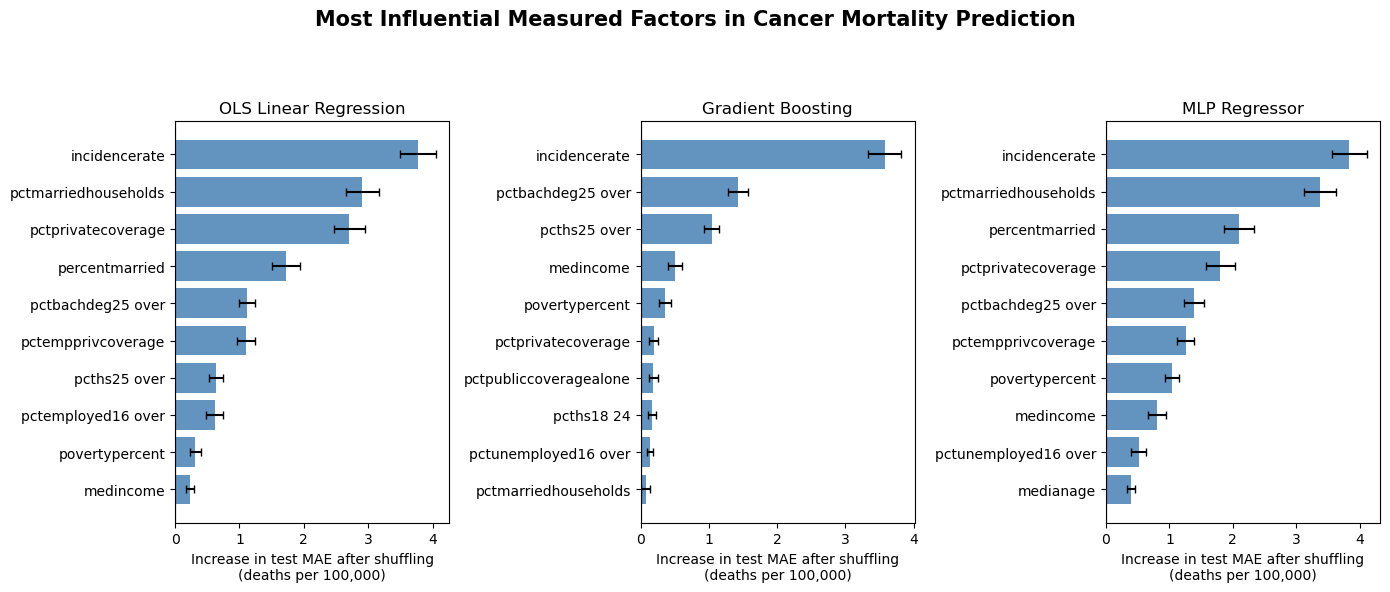


Top Cancer Predictors: OLS Linear Regression


,Feature,Mean Importance,Importance SD
0,incidencerate,3.773665,0.281173
1,pctmarriedhouseholds,2.911953,0.260124
2,pctprivatecoverage,2.709974,0.246829
3,percentmarried,1.721631,0.222863
4,pctbachdeg25_over,1.118981,0.118829



Top Cancer Predictors: Gradient Boosting


,Feature,Mean Importance,Importance SD
0,incidencerate,3.572998,0.247877
1,pctbachdeg25_over,1.426908,0.141662
2,pcths25_over,1.040807,0.108940
3,medincome,0.505150,0.101048
4,povertypercent,0.350992,0.087989



Top Cancer Predictors: MLP Regressor


,Feature,Mean Importance,Importance SD
0,incidencerate,3.836790,0.276002
1,pctmarriedhouseholds,3.372261,0.255147
2,percentmarried,2.090663,0.237028
3,pctprivatecoverage,1.802327,0.231417
4,pctbachdeg25_over,1.391748,0.158804


In [8]:
# This cell measures the importance of each retained cancer predictor.
# A predictor is shuffled while all other predictors remain unchanged.
# If shuffling increases testing MAE, the predictor was useful to the model.

cancer_importance_frames = []

fig, axes = plt.subplots(
    1,
    len(cancer_models),
    figsize=(14, 6)
)

axes = np.atleast_1d(axes)

for axis, (model_name, model) in zip(
    axes,
    cancer_models.items()
):
    # Calculate permutation importance using the testing data.
    # Negative MAE scoring makes a positive importance value represent
    # an increase in prediction error after the predictor is shuffled.
    importance_results = permutation_importance(
        model,
        x_test_cancer,
        y_test_cancer,
        scoring="neg_mean_absolute_error",
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    # Store the average importance and its variation
    model_importance_df = pd.DataFrame({
        "Feature": x_test_cancer.columns,
        "Mean Importance": importance_results.importances_mean,
        "Importance SD": importance_results.importances_std,
        "Model": model_name
    }).sort_values(
        "Mean Importance",
        ascending=False
    )

    cancer_importance_frames.append(model_importance_df)

    # Select the ten most influential measured factors
    top_factors = (
        model_importance_df
        .head(10)
        .sort_values("Mean Importance")
        .copy()
    )

    # Make the column names easier to read in the graph
    top_factors["Feature Label"] = (
        top_factors["Feature"]
        .str.replace("_", " ", regex=False)
    )

    axis.barh(
        top_factors["Feature Label"],
        top_factors["Mean Importance"],
        xerr=top_factors["Importance SD"],
        color="steelblue",
        alpha=0.85,
        capsize=3
    )

    axis.axvline(
        0,
        color="black",
        linewidth=0.8
    )

    axis.set_title(model_name)
    axis.set_xlabel(
        "Increase in test MAE after shuffling\n"
        "(deaths per 100,000)"
    )
    axis.set_ylabel("")

# Combine the results from both cancer models
cancer_importance_df = pd.concat(
    cancer_importance_frames,
    ignore_index=True
)

fig.suptitle(
    "Most Influential Measured Factors in Cancer Mortality Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.91])

plt.savefig(
    "cancer_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display the ten leading predictors from each model
for model_name in cancer_models:
    print(f"\nTop Cancer Predictors: {model_name}")

    display(
        cancer_importance_df[
            cancer_importance_df["Model"] == model_name
        ].head(5).drop(columns="Model")
        .reset_index(drop=True)
    )

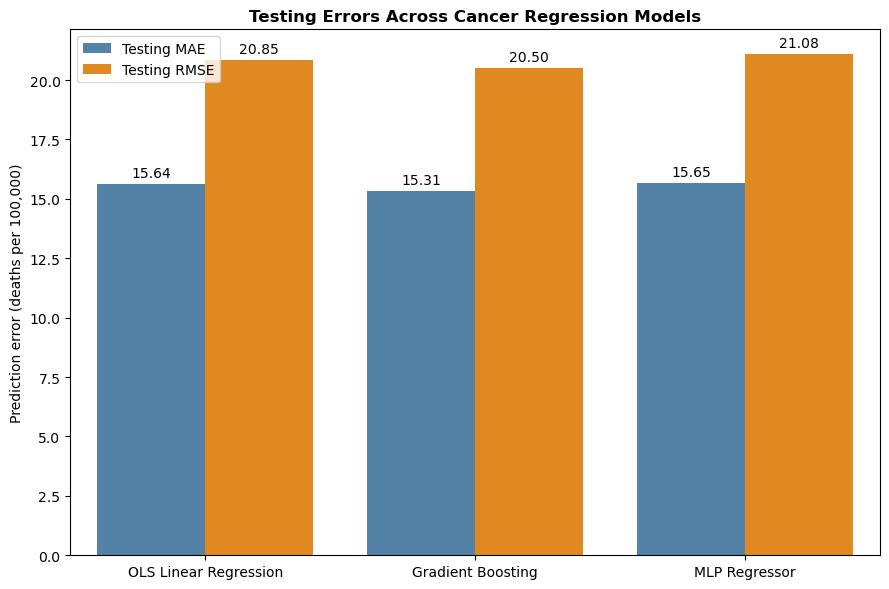

In [9]:
# This cell creates a grouped bar chart comparing the testing
# MAE and RMSE of all cancer regression models.
# Lower values indicate more accurate predictions.

#Selects the model name and testing-error columns
#melt func converts the table from wide into long format
#which allows seaborn to display MAE and RMSE as separate bars
cancer_error_plot = (
    cancer_results_df[
        ["Model", "Testing MAE", "Testing RMSE"]
    ]
    .melt(
        id_vars="Model", # Keeps each model name as an identifier
        var_name="Error Metric", #Store MAE or RMSE as metric name
        value_name="Error" #Store the corresponding metric value
    )
)

#Creates the figure that is 9 inches wide and 6 inches high
plt.figure(figsize=(9, 6))

#Creates the grouped bars for the two testing-error measirements
ax = sns.barplot(
    data=cancer_error_plot,
    x="Model", # Display each model on the horizontal axis
    y="Error", # Display prediction error on the vertical axis
    hue="Error Metric", # Create separate bars for MAE and RMSE
    palette=["steelblue", "darkorange"],
    errorbar=None
)

# Display exact values above the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )
#Add a descriptive title and axis labels
ax.set_title(
    "Testing Errors Across Cancer Regression Models",
    fontweight="bold"
)
# Remove the horizontal-axis label because the model names
# already identify the categories
ax.set_xlabel("")

# Both error metrics use the same units as the target variable
ax.set_ylabel("Prediction error (deaths per 100,000)")

# Display the legend without an additional legend title
ax.legend(title="")

plt.tight_layout()

# Save a high-resolution copy for the paper and PowerPoint
plt.savefig(
    "cancer_error_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

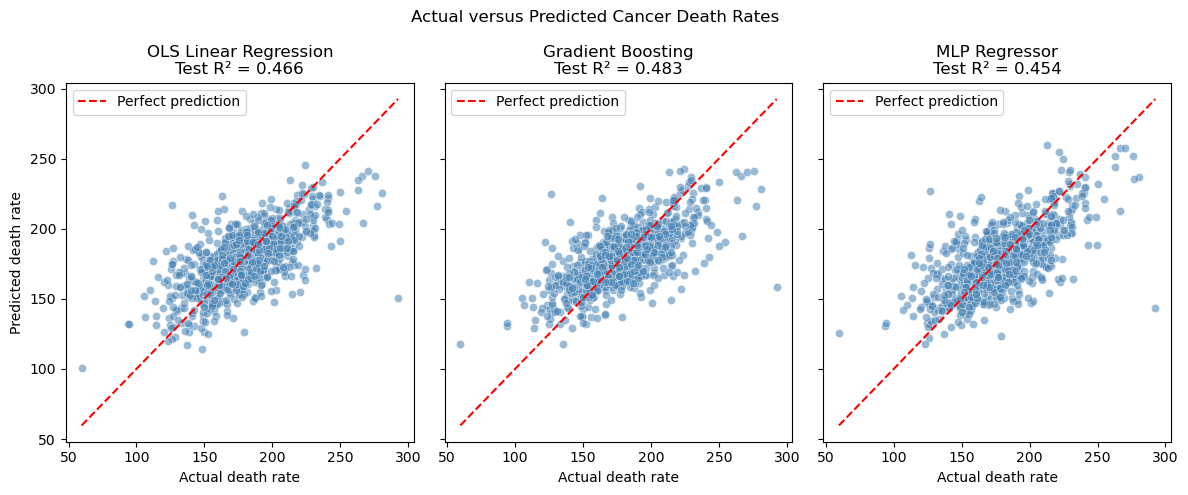

In [10]:
#This cell creates actual-versus-predicted scatterplots for each cancer regression model.


# Generate testing predictions from every fitted cancer model
# and store them in a dictionary using the model name as the key.
cancer_test_predictions = {
    model_name: model.predict(x_test_cancer)
    for model_name, model in cancer_models.items()
}

# Convert the actual testing target values into a NumPy array
# so they can be easily compared with the model predictions.
actual = y_test_cancer.to_numpy()


# Create one horizontal subplot for each cancer model.
# sharex and sharey use the same axis scales across both graphs,
# making the models easier to compare visually.
fig, axes = plt.subplots(
    1, len(cancer_test_predictions),
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

# Loop through each subplot and its corresponding model predictions
for ax, (model_name, predictions) in zip(
    axes, cancer_test_predictions.items()
):
    predictions = np.asarray(predictions) # Ensure that the predictions are stored as a NumPy array


    # Find the lowest and highest values needed for the
    # perfect-prediction reference line.
    lower = min(actual.min(), predictions.min())
    upper = max(actual.max(), predictions.max())

    # Plot actual cancer death rates on the horizontal axis
    # and predicted cancer death rates on the vertical axis.
    sns.scatterplot(
        x=actual,
        y=predictions,
        ax=ax,
        alpha=0.55, # Makes overlapping observations more visible
        s=35, # Controls the size of each observation
        color="steelblue"
    )

    # Perfect-prediction reference line
    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        color="red",
        label="Perfect prediction"
    )

    # Calculate the testing R² for the current model.
    # Higher R² values indicate that the model explains
    # more variation in the cancer death rate.
    test_r2 = r2_score(actual, predictions)

    # Add the model name and testing R² to the subplot title
    ax.set_title(f"{model_name}\nTest R² = {test_r2:.3f}")
    #Labels the horizontal and vertical axis
    ax.set_xlabel("Actual death rate")
    ax.set_ylabel("Predicted death rate")
    ax.legend()

# Add one overall title above both model graphs
plt.suptitle("Actual versus Predicted Cancer Death Rates")
plt.tight_layout()

# Save a high-resolution copy for the report and PowerPoint
plt.savefig(
    "cancer_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Part 4: Stroke dataset and model analysis

In [11]:
# This cell trains and evaluates two classification models
# used to predict whether a patient experienced a stroke.


# Create the two stroke classification models
stroke_models = {
    #Logistic regression that provides a relatively simple and interpretable classification benchmark
    "Logistic Regression": LogisticRegression(solver = 'liblinear', random_state = 42),

    #MLPClassifier is a neural-network classification model.
    "MLP Classifier":  MLPClassifier(hidden_layer_sizes = (90,), # Creates one hidden layer containing 60 neurons
                              activation = "logistic", #uses a logistic/sigmoid activation function in hidden layer
                              solver = 'sgd', # Uses stochastic gradient descent to update the model's weights
                              learning_rate_init = 0.05,  # Controls how much the weights change during each update
                              max_iter = 15000, # Sets the maximum number of training iterations
                              random_state = 42 # Makes the neural-network results reproducible
                             )
}

# Assign the probability threshold used by each model.
# A patient is classified as Stroke when the predicted
# probability is at least above the threshold
stroke_thresholds = {
    "Logistic Regression": 0.39,
    "MLP Classifier": 0.39
}
# Empty list used to store the performance results
stroke_results = []

# Empty dictionary used to store each model's test predictions.
# These predictions are later used for the confusion matrices
# and classification reports.
stroke_test_predictions = {}

#Train and evaluate both models using the same datasets
for model_name, model in stroke_models.items():

    # Begin measuring computation time
    start_time = perf_counter()

    # Train the model using only the stroke training data
    model.fit(x_train_stroke,y_train_stroke)

    # Retrieve the manually selected threshold for the current model
    threshold = stroke_thresholds[model_name]

    # Convert probabilities into binary predictions.
    # A probability of at least the threshold becomes Stroke (1);
    # Otherwise, the prediction becomes No Stroke (0).
    train_probabilities = model.predict_proba(x_train_stroke)[:, 1]
    test_probabilities = model.predict_proba(x_test_stroke)[:, 1]
    train_predictions = (train_probabilities >= threshold).astype(int)
    test_predictions = (test_probabilities >= threshold).astype(int)

    
    # Measure the time required to fit the model
    # and generate its predictions.
    computation_time = perf_counter() - start_time

    # Save the test predictions for later evaluation
    stroke_test_predictions[model_name] = test_predictions

    # Calculate training and testing accuracy
    train_accuracy = accuracy_score(y_train_stroke, train_predictions)
    test_accuracy = accuracy_score(y_test_stroke, test_predictions)

    # Extract the four confusion-matrix outcomes:
    # tn = correctly predicted No Stroke
    # fp = incorrectly predicted Stroke
    # fn = actual strokes that the model missed
    # tp = correctly predicted Stroke
    tn,fp,fn,tp = confusion_matrix(y_test_stroke,test_predictions).ravel()
    

     #Store the model's performance measurements
    stroke_results.append({"Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Accuracy Gap": abs(train_accuracy - test_accuracy), # A larger difference can indicate overfitting
        # Confusion-matrix results
        "Correct No Stroke": tn,
        "Incorrect Stroke": fp,
        "Missed Stroke": fn,
        "Correct Stroke": tp,
        # Time required to fit the model and generate predictions                   
        "Computation Time": perf_counter() - start_time
    })
# Convert the stored model results into a comparison table      
stroke_results_df = pd.DataFrame(stroke_results)

stroke_results_df

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Correct No Stroke,Incorrect Stroke,Missed Stroke,Correct Stroke,Computation Time
0,Logistic Regression,0.950797,0.952381,0.001584,1457,1,72,3,0.061407
1,MLP Classifier,0.951356,0.952381,0.001025,1458,0,73,2,0.528631


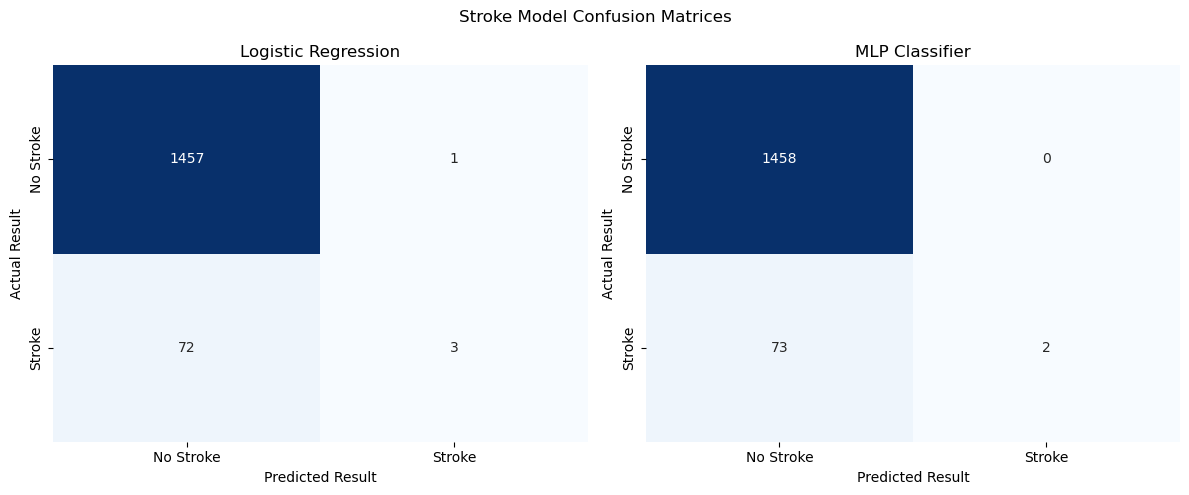

In [12]:
# This cell creates one confusion-matrix heatmap for each
# stroke classification model.


# Create one horizontal subplot for every fitted stroke model.
# The number of graphs automatically matches the number of
# models stored in stroke_test_predictions.
fig, axes = plt.subplots(
    1,
    len(stroke_test_predictions),
    figsize=(12, 5)
)

# Loop through each model's stored testing predictions
for axis, (model_name, predictions) in zip(
    axes,
    stroke_test_predictions.items()
):
    # Create the confusion matrix using:
    # 0 = No Stroke
    # 1 = Stroke
    #
    # Matrix arrangement:
    # [[True Negative,  False Positive],
    #  [False Negative, True Positive]]
    matrix = confusion_matrix(
        y_test_stroke,
        predictions,
        labels=[0, 1]
    )

    # Display the confusion matrix as a Seaborn heatmap
    sns.heatmap(
        matrix,
        annot=True, #Displays the number inside each cell
        fmt="d", # Display values as whole numbers
        cmap="Blues",
        cbar=False, # Remove the color-scale bar
        xticklabels=["No Stroke", "Stroke"],
        yticklabels=["No Stroke", "Stroke"],
        ax=axis
    )

    # Add the model name above its confusion matrix
    axis.set_title(model_name)

    # Columns represent the model's predictions
    axis.set_xlabel("Predicted Result")

     # Rows represent the patients' actual outcomes
    axis.set_ylabel("Actual Result")

# Add one overall title above both confusion matrices
plt.suptitle("Stroke Model Confusion Matrices")
plt.tight_layout()

# Save a high-resolution image for the report and PowerPoint
fig.savefig(
    "stroke_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [13]:
# This cell prints a classification report for each stroke model.
# The report includes precision, recall, F1-score, and support
# for both the No Stroke and Stroke classes to compare.


# Loop through the stored testing predictions from each model
for model_name, predictions in stroke_test_predictions.items():


    #Print the name of the model above its re
    print(f"\nClassification Report: {model_name}")

    print(
        classification_report(
            y_test_stroke, # Actual stroke outcomes
            predictions, # Predicted stroke outcomes
            labels=[0, 1], # Specify the order of the binary outcome labels
            target_names=["No Stroke", "Stroke"], # Replace the numerical labels with descriptive names
            digits=3, # Display metric values to three decimal places
            zero_division=0 # Return zero instead of producing a warning when a model does not predict any observations in a class
        )
    )


Classification Report: Logistic Regression
              precision    recall  f1-score   support

   No Stroke      0.953     0.999     0.976      1458
      Stroke      0.750     0.040     0.076        75

    accuracy                          0.952      1533
   macro avg      0.851     0.520     0.526      1533
weighted avg      0.943     0.952     0.932      1533


Classification Report: MLP Classifier
              precision    recall  f1-score   support

   No Stroke      0.952     1.000     0.976      1458
      Stroke      1.000     0.027     0.052        75

    accuracy                          0.952      1533
   macro avg      0.976     0.513     0.514      1533
weighted avg      0.955     0.952     0.930      1533



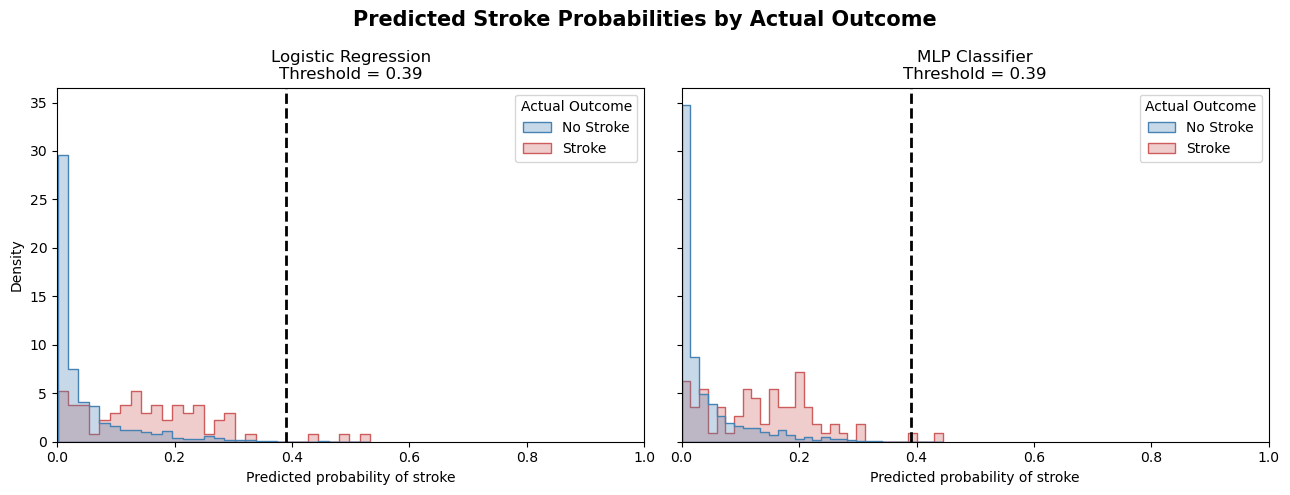

In [14]:
# This cell creates probability-distribution graphs showing
# how each stroke model assigns probabilities to patients
# who actually experienced a stroke and those who did not.

#Creates an empty list for storing each model's probability table
stroke_probability_frames = []


#Generate predicted stroke probabilities for each fitted model
for model_name, model in stroke_models.items():

    # predict_proba() returns two columns:
    # column 0 = probability of No Stroke
    # column 1 = probability of Stroke
    stroke_probabilities = model.predict_proba(
        x_test_stroke
    )[:, 1]

    # Create a DataFrame containing each patient's predicted
    # stroke probability, actual outcome, and model name.
    model_probability_df = pd.DataFrame({
        "Predicted Stroke Probability": stroke_probabilities,
        "Actual Outcome": np.where(
            y_test_stroke.to_numpy() == 1,
            "Stroke",
            "No Stroke"
        ),
        "Model": model_name
    })

    # Add the current model's probability table to the list
    stroke_probability_frames.append(
        model_probability_df
    )


# Combine the probability tables from both models into
# one DataFrame for visualization.
stroke_probability_df = pd.concat(
    stroke_probability_frames,
    ignore_index=True
)

# Create one horizontal subplot for each stroke model.
# Both graphs use the same horizontal and vertical scales
# so their probability distributions can be compared.
fig, axes = plt.subplots(
    1,
    len(stroke_models),
    figsize=(13, 5),
    sharex=True,
    sharey=True
)

# Ensure axes remains iterable if only one model is used
axes = np.atleast_1d(axes)

# Create a separate probability-distribution graph for each model
for axis, model_name in zip(
    axes,
    stroke_models.keys()
):
    # Select probability observations generated by the current model
    model_data = stroke_probability_df[
        stroke_probability_df["Model"] == model_name
    ]

    # Retrieve the manually selected classification threshold
    # used by the current model.
    threshold = stroke_thresholds[model_name]

    # Plot separate probability distributions for patients
    # with and without an actual stroke.
    sns.histplot(
        data=model_data,
        x="Predicted Stroke Probability",
        hue="Actual Outcome",

        # Keep the outcome categories in a consistent order
        hue_order=["No Stroke", "Stroke"],
        # Use blue for No Stroke and red for Stroke
        palette={
            "No Stroke": "steelblue",
            "Stroke": "indianred"
        },
        bins=30, # Divide probabilities into 30 intervals
        stat="density", # Display density instead of raw patient counts so the
        # smaller Stroke class remains visible.
        common_norm=False, # Normalize the Stroke and No Stroke distributions separately
        element="step", # Draw the edge of each histogram distribution
        fill=True,  # Fill the histogram distributions
        alpha=0.30, # Make overlapping areas visible
        ax=axis # Place the graph in its assigned subplot
    )

    # Display the manually selected classification threshold.
    # Probabilities at or above this line become Stroke predictions.
    axis.axvline(
        x=threshold,
        color="black",
        linestyle="--",
        linewidth=2,
    )
    # Keep the probability axis between 0% and 100%
    axis.set_xlim(0, 1)

    # Display the model name and threshold above each subplot
    axis.set_title(f"{model_name}\nThreshold = {threshold:.2f}")

    # Add descriptive axis labels
    axis.set_xlabel("Predicted probability of stroke")
    axis.set_ylabel("Density") # Density represents the shape of each distribution,
    # not the raw number of patients.

# Add one overall title above both model graphs
fig.suptitle(
    "Predicted Stroke Probabilities by Actual Outcome",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

# Save a high-resolution copy for the paper and PowerPoint
plt.savefig(
    "stroke_probability_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

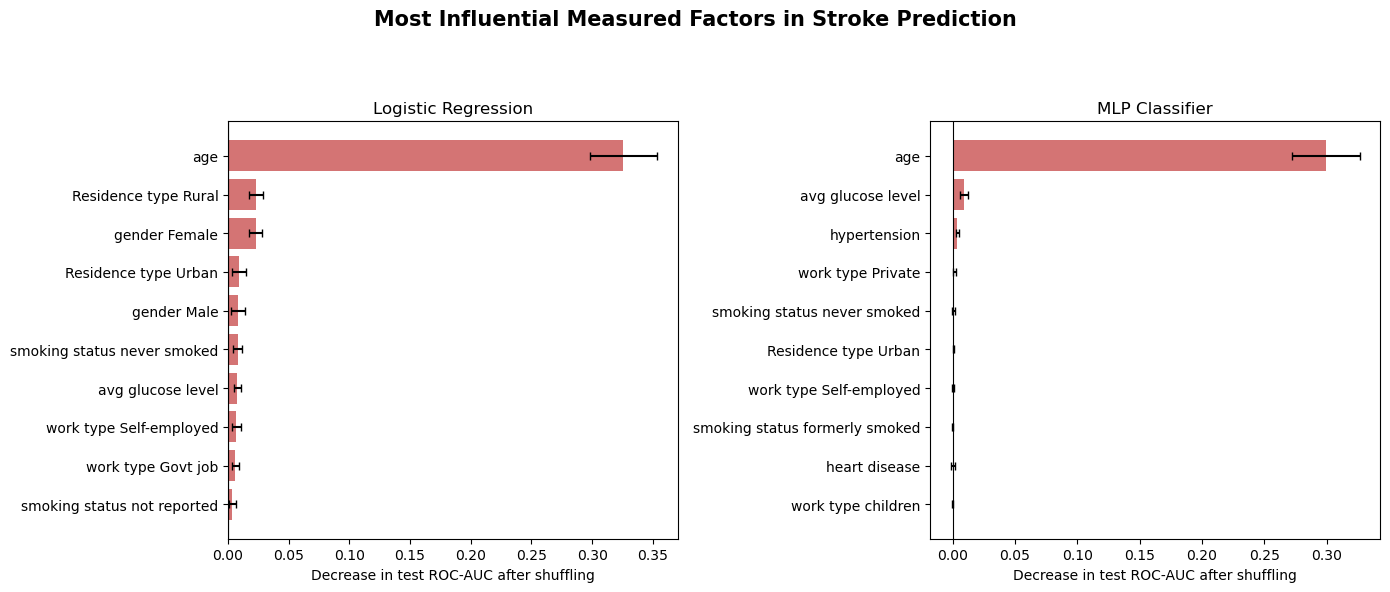


Top Stroke Predictors: Logistic Regression


,Feature,Mean Importance,Importance SD,Model
0,age,0.325446,0.027599,Logistic Regression
1,Residence_type_Rural,0.023048,0.006089,Logistic Regression
2,gender_Female,0.022610,0.005096,Logistic Regression
3,Residence_type_Urban,0.008997,0.005923,Logistic Regression
4,gender_Male,0.007917,0.005845,Logistic Regression



Top Stroke Predictors: MLP Classifier


,Feature,Mean Importance,Importance SD,Model
20,age,0.299094,0.027198,MLP Classifier
21,avg_glucose_level,0.009171,0.002896,MLP Classifier
22,hypertension,0.003901,0.001434,MLP Classifier
23,work_type_Private,0.001552,0.000853,MLP Classifier
24,smoking_status_never smoked,0.000598,0.001243,MLP Classifier


In [15]:
# This cell measures how strongly each retained stroke predictor
# contributes to the model's ability to separate Stroke from No Stroke.

stroke_importance_frames = []

fig, axes = plt.subplots(
    1,
    len(stroke_models),
    figsize=(14, 6)
)

axes = np.atleast_1d(axes)

for axis, (model_name, model) in zip(
    axes,
    stroke_models.items()
):
    # ROC-AUC is used instead of accuracy because the stroke dataset
    # contains substantially more No Stroke than Stroke observations.
    # It also evaluates predicted probabilities independently of the
    # manually selected classification threshold.
    importance_results = permutation_importance(
        model,
        x_test_stroke,
        y_test_stroke,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    model_importance_df = pd.DataFrame({
        "Feature": x_test_stroke.columns,
        "Mean Importance": importance_results.importances_mean,
        "Importance SD": importance_results.importances_std,
        "Model": model_name
    }).sort_values(
        "Mean Importance",
        ascending=False
    )

    stroke_importance_frames.append(model_importance_df)

    top_factors = (
        model_importance_df
        .head(10)
        .sort_values("Mean Importance")
        .copy()
    )

    top_factors["Feature Label"] = (
        top_factors["Feature"]
        .str.replace("_", " ", regex=False)
    )

    axis.barh(
        top_factors["Feature Label"],
        top_factors["Mean Importance"],
        xerr=top_factors["Importance SD"],
        color="indianred",
        alpha=0.85,
        capsize=3
    )

    axis.axvline(
        0,
        color="black",
        linewidth=0.8
    )

    axis.set_title(model_name)
    axis.set_xlabel(
        "Decrease in test ROC-AUC after shuffling"
    )
    axis.set_ylabel("")

stroke_importance_df = pd.concat(
    stroke_importance_frames,
    ignore_index=True
)

fig.suptitle(
    "Most Influential Measured Factors in Stroke Prediction",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.91])

plt.savefig(
    "stroke_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display the ten leading predictors from each model
for model_name in stroke_models:
    print(f"\nTop Stroke Predictors: {model_name}")

    display(
        stroke_importance_df[
            stroke_importance_df["Model"] == model_name
        ].head(5)
    )